# EDA section

### 0. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re

### 1. Load dataset

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### 2. Dataset overview

In [3]:
df.shape

(5572, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [5]:
df.dtypes

v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object

### 3.Missing values

In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

### 4. Duplicate data

In [7]:
df.duplicated().sum()

np.int64(403)

In [8]:
df = df.drop_duplicates()

### 5. Class Distribution

In [9]:
df["v1"].value_counts()

v1
ham     4516
spam     653
Name: count, dtype: int64

In [10]:
df["v2"].value_counts()

v2
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                                      1
Ok lar... Joking wif u oni...                                                                                                                                        1
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's          1
U dun say so early hor... U c already then say...                                                                                                                    1
Nah I don't think he goes to usf, he lives around here though                                                                                                        1
                                                                                                                                                                  

# Text classification section

### 1. Import libraries

In [11]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt")
nltk.download('punkt_tab')

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 2.Load dataset

In [12]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [13]:
df = df[["v1","v2"]]

df.columns = ["label","text"]

In [14]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 3.Text cleaning

In [15]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [16]:
df["clean_text"] = df["text"].apply(clean_text)

In [17]:
df[["text","clean_text"]].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


### 4.Tokenization

In [18]:
df["tokens"] = df["clean_text"].apply(word_tokenize)

### 5. Train/Test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

### 6. CountVectorizer

In [20]:
count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

In [21]:
print(X_train_count.shape)

(4457, 7522)


### 7. TF-IDF

In [22]:
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

### 8. Train naive bayes

In [23]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

### 9. Train Logistic Regression

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

### 10. Evaluation

In [25]:
def evaluate_model(model_name, y_true, y_pred):

    print("="*40)
    print(model_name)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, pos_label="spam"))
    print("Recall   :", recall_score(y_true, y_pred, pos_label="spam"))
    print("F1-score :", f1_score(y_true, y_pred, pos_label="spam"))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

In [26]:
evaluate_model("Naive Bayes", y_test, y_pred_nb)

evaluate_model("Logistic Regression", y_test, y_pred_lr)

Naive Bayes
Accuracy : 0.9542600896860987
Precision: 1.0
Recall   : 0.6577181208053692
F1-score : 0.7935222672064778

Classification Report
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       966
        spam       1.00      0.66      0.79       149

    accuracy                           0.95      1115
   macro avg       0.97      0.83      0.88      1115
weighted avg       0.96      0.95      0.95      1115

Logistic Regression
Accuracy : 0.968609865470852
Precision: 0.9913793103448276
Recall   : 0.7718120805369127
F1-score : 0.8679245283018868

Classification Report
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### 11. Confusion matrix

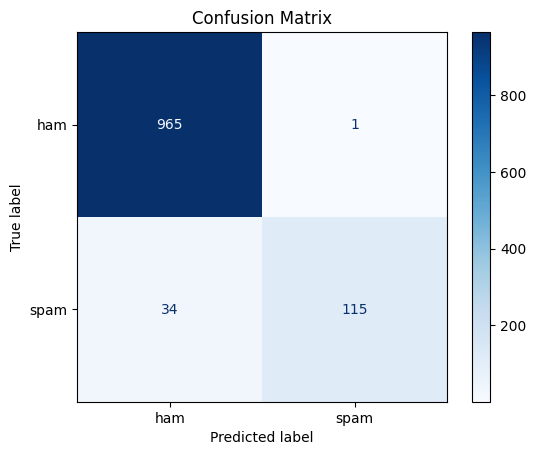

In [27]:
# logistics regression
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham","spam"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

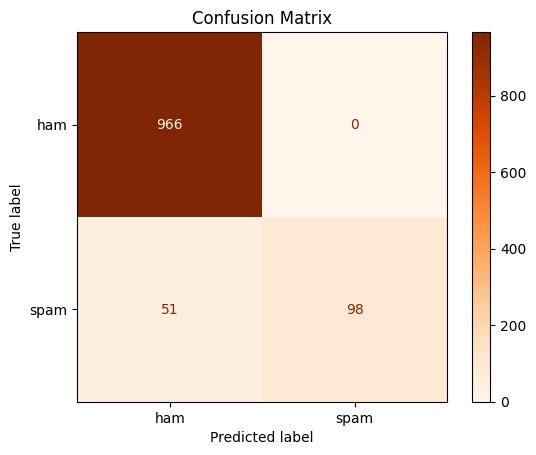

In [28]:
# naive bayes
cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham","spam"]
)

disp.plot(cmap="Oranges")

plt.title("Confusion Matrix")

plt.show()

### 12. Analyze wrong predictions 

In [29]:
# logistics regressions
results = pd.DataFrame({
    "Text": X_test,
    "True Label": y_test,
    "Predicted Label": y_pred_lr
})

wrong_predictions = results[
    results["True Label"] != results["Predicted Label"]
]

wrong_predictions.head(5)

,Text,True Label,Predicted Label
5,freemsg hey there darling its been weeks now a...,spam,ham
1021,guess what somebody you know secretly fancies ...,spam,ham
3748,dear voucher holder claim your st class airpor...,spam,ham
855,talk sexy make new friends or fall in love in ...,spam,ham
3139,sexy sexy cum and text me im wet and warm and ...,spam,ham


In [30]:
# naive bayes
results = pd.DataFrame({
    "Text": X_test,
    "True Label": y_test,
    "Predicted Label": y_pred_nb
})

wrong_predictions = results[
    results["True Label"] != results["Predicted Label"]
]

wrong_predictions.head(5)

,Text,True Label,Predicted Label
3057,you are now unsubscribed all services get tons...,spam,ham
5,freemsg hey there darling its been weeks now a...,spam,ham
1021,guess what somebody you know secretly fancies ...,spam,ham
3748,dear voucher holder claim your st class airpor...,spam,ham
855,talk sexy make new friends or fall in love in ...,spam,ham
